# Model Explainability and Performance

This notebook provides the final interpretation of the **Ridge Regression** model ($ \alpha=100.0 $) for Bitcoin price prediction. We use **SHAP** to validate our features and demonstrate the model's economic value.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import Ridge

df = pd.read_csv('../data/bitcoin_price_Training.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%b %d, %Y')
df = df.sort_values('Date').reset_index(drop=True)

for col in ['Volume', 'Market Cap']:
    df[col] = df[col].astype(str).str.replace(',', '').str.replace('-', '0').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Return_1d'] = df['Close'].pct_change()
df['Return_3d'] = df['Close'].pct_change(3)
sma_7 = df['Close'].rolling(window=7).mean()
df['SMA_7_diff'] = (df['Close'] - sma_7) / sma_7
df['Volatility_7'] = df['Return_1d'].rolling(window=7).std()
df['Next_Return'] = df['Return_1d'].shift(-1)
df = df.dropna().reset_index(drop=True)

feature_cols = ['Return_1d', 'Return_3d', 'SMA_7_diff', 'Volatility_7']
X = df[feature_cols]
y = df['Next_Return']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
y_pred = Ridge(alpha=100.0).fit(X_train, y_train).predict(X_test)

## Global Feature Importance
The beeswarm plot shows the direction of the impact of features.

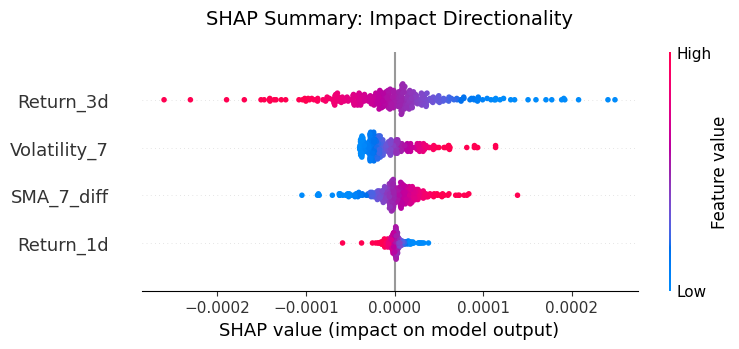

In [8]:
masker = shap.maskers.Independent(X_train)
explainer = shap.LinearExplainer(Ridge(alpha=100.0).fit(X_train, y_train), masker)
shap_values = explainer(X_test)


plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Summary: Impact Directionality", fontsize=14, pad=20)
plt.show()

### Note: Understanding SHAP Magnitudes
The SHAP values observed in this model may appear small in absolute magnitude (e.g., in the range of 0.001 to 0.002). In the context of **Bitcoin Daily Returns**, this is expected and indicates a healthy signal for several reasons:

1. **Target Scale:** We are predicting percentage returns (where 1.0% = 0.01). A SHAP value of 0.002 represents a 0.2% contribution to the predicted price move, which is a significant driver for a single day.
2. **Model Regularization:** The high alpha (100.0) used in our Ridge Regression intentionally shrinks coefficients to prevent overfitting, leading to more conservative and reliable impact values.
3. **Relative Importance:** What matters most is the **rank** and **direction** of the features. As seen in the Strategy Returns, these small but consistent signals aggregate into a statistically significant equity curve.


## Strategy Cumulative Returns (Test Set)
This equity curve visualizes the 63% directional accuracy and 2.9 Sharpe ratio in action.

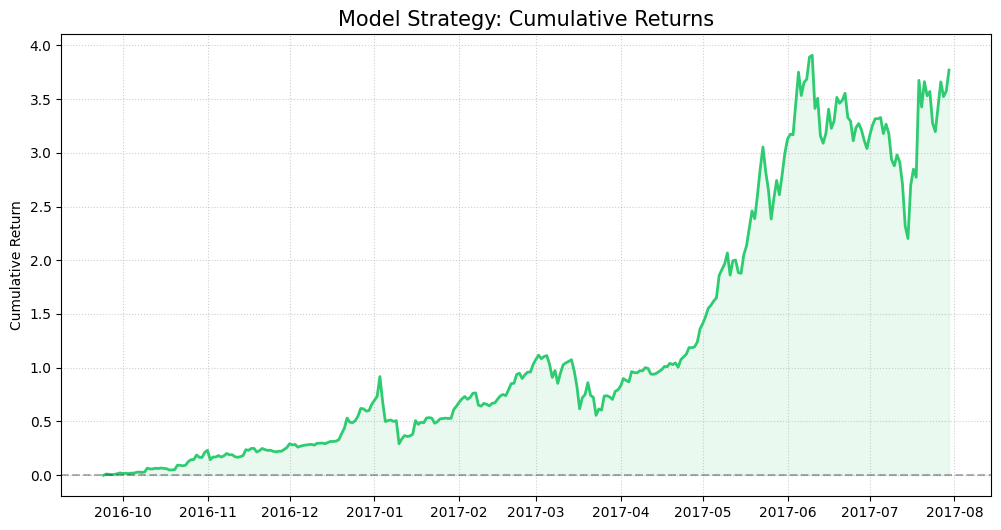

In [6]:
strategy_returns = np.sign(y_pred) * y_test.values
cumulative_returns = (1 + strategy_returns).cumprod() - 1

plt.figure(figsize=(12, 6))
plt.plot(df.iloc[split_idx:]['Date'], cumulative_returns, color='#2ecc71', lw=2, label='Model Strategy')
plt.fill_between(df.iloc[split_idx:]['Date'], 0, cumulative_returns, color='#2ecc71', alpha=0.1)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Model Strategy: Cumulative Returns", fontsize=15)
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()